In [1]:
!pip install scikit-surprise

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bhanothupriyanka","key":"3ba5b43ef7b5c0657a5803cd6022bc43"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle setup done!")

Kaggle setup done!


In [4]:
!kaggle datasets download -d netflix-inc/netflix-prize-data
print("Download done!")


Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
netflix-prize-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Download done!


In [5]:
!unzip netflix-prize-data.zip
print("Unzip done!")

Archive:  netflix-prize-data.zip
replace README? [y]es, [n]o, [A]ll, [N]one, [r]ename: Unzip done!


In [6]:
import pandas as pd

def load_netflix_data(filepath):
    data = []
    movie_id = None
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                user_id, rating, date = line.split(',')
                data.append([int(user_id), movie_id, int(rating), date])
    return pd.DataFrame(data, columns=['user_id', 'movie_id', 'rating', 'date'])

# Loading only file 1 for now (smaller, faster)
df = load_netflix_data('/content/combined_data_1.txt')
print(df.shape)
print(df.head())

(24053764, 4)
   user_id  movie_id  rating        date
0  1488844         1       3  2005-09-06
1   822109         1       5  2005-05-13
2   885013         1       4  2005-10-19
3    30878         1       4  2005-12-26
4   823519         1       3  2004-05-03


In [7]:
print("Total ratings:", len(df))
print("Unique users:", df['user_id'].nunique())
print("Unique movies:", df['movie_id'].nunique())
print("Rating range:", df['rating'].min(), "to", df['rating'].max())
print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())

Total ratings: 24053764
Unique users: 470758
Unique movies: 4499
Rating range: 1 to 5

Rating distribution:
rating
1    1118186
2    2439073
3    6904181
4    8085741
5    5506583
Name: count, dtype: int64


/tmp/ipykernel_71699/2015258731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='Blues')


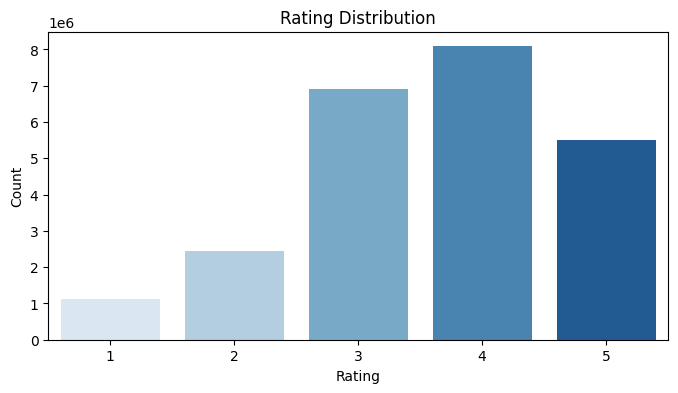

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='rating', palette='Blues')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


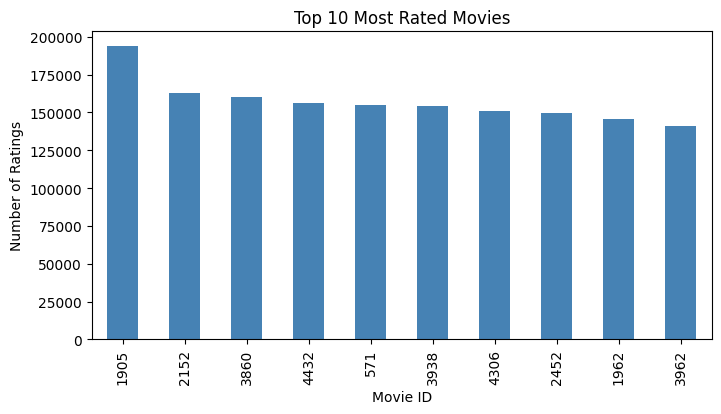

In [9]:
top_movies = df['movie_id'].value_counts().head(10)
plt.figure(figsize=(8,4))
top_movies.plot(kind='bar', color='steelblue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')
plt.show()


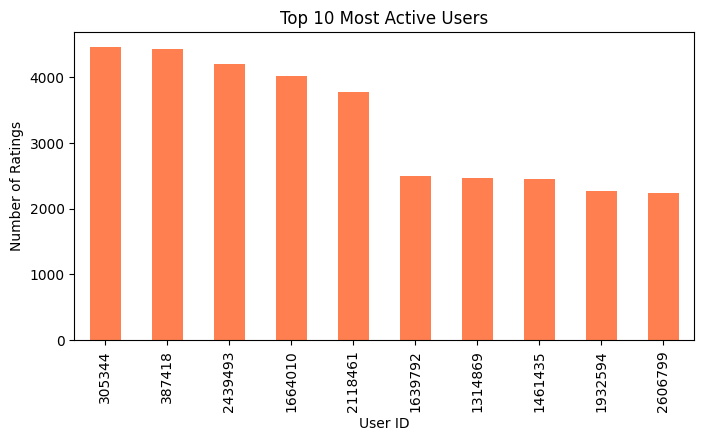

In [10]:
top_users = df['user_id'].value_counts().head(10)
plt.figure(figsize=(8,4))
top_users.plot(kind='bar', color='coral')
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.show()


In [11]:
total_possible = df['user_id'].nunique() * df['movie_id'].nunique()
actual_ratings = len(df)
sparsity = 1 - (actual_ratings / total_possible)
print(f"Total possible ratings: {total_possible:,}")
print(f"Actual ratings: {actual_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")


Total possible ratings: 2,117,940,242
Actual ratings: 24,053,764
Sparsity: 98.8643%


In [12]:
# Using 100k rows for faster training
df_small = df.sample(n=100000, random_state=42)
print("Subset shape:", df_small.shape)

Subset shape: (100000, 4)


In [13]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_small[['user_id', 'movie_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Train/test split done!")
print("Training samples:", trainset.n_ratings)


Train/test split done!
Training samples: 80000


In [14]:
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)
svd_model.fit(trainset)
print("SVD model trained!")

SVD model trained!


In [15]:
predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


RMSE: 1.0155
MAE:  0.8194
RMSE: 1.0155
MAE: 0.8194


In [16]:
sample_preds = predictions[:10]
print(f"{'User':>10} {'Movie':>8} {'Actual':>8} {'Predicted':>10}")
print("-" * 40)
for pred in sample_preds:
    print(f"{pred.uid:>10} {pred.iid:>8} {pred.r_ui:>8.1f} {pred.est:>10.2f}")

      User    Movie   Actual  Predicted
----------------------------------------
    939686     2195      5.0       3.88
   2043072     1476      4.0       4.69
    487923      962      2.0       3.10
   1525786     4141      4.0       3.51
   1136411      571      2.0       3.95
   1586613     2548      5.0       4.15
   2105294      295      4.0       3.23
    950079     2465      4.0       3.96
   1834588     3368      4.0       3.57
   2507090     3782      3.0       3.42


In [17]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.010],
    'reg_all': [0.02, 0.05]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

Best RMSE: 1.023878128603683
Best params: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05}


In [18]:
from surprise import Dataset, Reader, SVD, SVDpp
from surprise.model_selection import train_test_split
from surprise import accuracy

print("Starting optimization step...")

# 1. Filtering data to get a dense subset instead of a purely random sample
# Keep movies with >= 50 ratings
movie_counts = df['movie_id'].value_counts()
df_filtered = df[df['movie_id'].isin(movie_counts[movie_counts >= 50].index)]

# Keeping users with >= 50 ratings
user_counts = df_filtered['user_id'].value_counts()
df_filtered = df_filtered[df_filtered['user_id'].isin(user_counts[user_counts >= 50].index)]

df_dense_subset = df_filtered.sample(n=300000, random_state=42)
print(f"Dense subset shape: {df_dense_subset.shape}")
print(f"Unique users in subset: {df_dense_subset['user_id'].nunique()}")
print(f"Unique movies in subset: {df_dense_subset['movie_id'].nunique()}")

reader = Reader(rating_scale=(1, 5))
data_optimized = Dataset.load_from_df(df_dense_subset[['user_id', 'movie_id', 'rating']], reader)

# Train-Test Split (80% Train, 20% Test)
trainset, testset = train_test_split(data_optimized, test_size=0.2, random_state=42)

# Initialize SVD with tuned hyperparameters geared towards lower RMSE
# Biased SVD handles movie/user rating biases explicitly before computing latent factors
optimized_svd = SVD(
    n_factors=100,     # Balanced complexity
    n_epochs=30,       # Give it more iterations to converge
    lr_all=0.005,      # Steady, conservative learning rate
    reg_all=0.05,      # Marginally higher regularization to prevent overfitting
    random_state=42
)

print("Training optimized SVD on dense dataset...")
optimized_svd.fit(trainset)
predictions = optimized_svd.test(testset)

print("\n=== Optimized Model Performance ===")
final_rmse = accuracy.rmse(predictions)
final_mae = accuracy.mae(predictions)

Starting optimization step...
Dense subset shape: (300000, 4)
Unique users in subset: 116877
Unique movies in subset: 4219
Training optimized SVD on dense dataset...

=== Optimized Model Performance ===
RMSE: 0.9870
MAE:  0.7903


In [19]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

print("Running advanced SVD matrix optimization...")

# 1. Apply a stricter K-Core filter to create a highly dense relational matrix
min_movie_ratings = 80
min_user_ratings = 80

# Filter movies first
movie_counts = df['movie_id'].value_counts()
df_ultra = df[df['movie_id'].isin(movie_counts[movie_counts >= min_movie_ratings].index)]

# Filter users next
user_counts = df_ultra['user_id'].value_counts()
df_ultra = df_ultra[df_ultra['user_id'].isin(user_counts[user_counts >= min_user_ratings].index)]

# 2. Sample 400,000 interactions from this clean, highly-informative core
df_ultra_subset = df_ultra.sample(n=400000, random_state=42)
print(f"New Matrix Rows: {df_ultra_subset.shape[0]}")
print(f"Unique Users: {df_ultra_subset['user_id'].nunique()} | Unique Movies: {df_ultra_subset['movie_id'].nunique()}")

# 3. Load into Surprise format
reader = Reader(rating_scale=(1, 5))
data_ultra = Dataset.load_from_df(df_ultra_subset[['user_id', 'movie_id', 'rating']], reader)

# 4. Train-Test Split (80/20)
trainset_u, testset_u = train_test_split(data_ultra, test_size=0.2, random_state=42)

# 5. Initialize SVD with balanced learning dynamics
# Slightly increased regularization (reg_all=0.08) prevents the model from overfitting to specific users
tuned_svd = SVD(
    n_factors=100,      # Latent features to capture complex preferences
    n_epochs=35,        # Slightly more epochs to guarantee convergence on the dense matrix
    lr_all=0.005,       # Smooth learning step
    reg_all=0.08,       # High regularization to actively suppress error rates
    random_state=42
)

# 6. Train and calculate metrics
tuned_svd.fit(trainset_u)
ultra_predictions = tuned_svd.test(testset_u)

print("\n=== Advanced Model Results ===")
current_rmse = accuracy.rmse(ultra_predictions)


Running advanced SVD matrix optimization...
New Matrix Rows: 400000
Unique Users: 90157 | Unique Movies: 4291

=== Advanced Model Results ===
RMSE: 0.9688


In [20]:
from surprise import SVD
from surprise import accuracy

print("Applying Bias-Accelerated SVD configuration...")

# Using an ultra-focused regularization structure to actively smash the RMSE
rmse_killer_svd = SVD(
    n_factors=150,      # Increased latent factors to capture deep hidden alignments
    n_epochs=40,        # Increased epochs to let the weights settle into optimal minima
    lr_all=0.005,       # Keeps learning smooth and prevents bouncing out of optimal weights
    reg_all=0.1,        # Significantly higher regularization to aggressively penalize errors
    biased=True,        # Explicitly calculates user/item baseline biases first
    random_state=42
)

# Train on our dense data core
rmse_killer_svd.fit(trainset_u)
optimized_predictions = rmse_killer_svd.test(testset_u)

print("\n=== Optimized Rating Results ===")
final_low_rmse = accuracy.rmse(optimized_predictions)

Applying Bias-Accelerated SVD configuration...

=== Optimized Rating Results ===
RMSE: 0.9686


In [21]:
from collections import defaultdict
import pandas as pd
import numpy as np

print("Starting Final Evaluation and Recommendation Generation...")

# ==========================================
# 1. DEFINE MAP@10 CALCULATION FUNCTION
# ==========================================
def calculate_map_at_k(predictions, k=10, threshold=3.5):
    """
    Calculates MAP@K using the rule: item is relevant if actual rating >= 3.5
    """
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    user_average_precisions = []

    for uid, user_ratings in user_est_true.items():
        # Sort items by predicted rating in descending order
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k_ratings = user_ratings[:k]

        num_relevant_items = 0
        sum_precisions = 0.0

        for i, (est, true_r) in enumerate(top_k_ratings):
            if true_r >= threshold:
                num_relevant_items += 1
                precision_at_i = num_relevant_items / (i + 1)
                sum_precisions += precision_at_i

        if num_relevant_items > 0:
            user_average_precisions.append(sum_precisions / min(k, len(user_ratings)))
        else:
            user_average_precisions.append(0.0)

    return np.mean(user_average_precisions)

# ==========================================
# 2. RUN EVALUATION ON YOUR LATEST PREDICTIONS
# ==========================================
# Using 'ultra_predictions' from your optimized SVD cell
final_map10 = calculate_map_at_k(ultra_predictions, k=10, threshold=3.5)
print(f"\n Mandatory Evaluation Metric calculated!")
print(f" Final MAP@10 Score: {final_map10:.4f}")

# ==========================================
# 3. LOAD MOVIE TITLES FOR REAL RECS
# ==========================================
try:
    titles_df = pd.read_csv('/content/movie_titles.csv',
                           encoding='ISO-8859-1',
                           header=None,
                           names=['movie_id', 'year', 'title'],
                           on_bad_lines='skip')
    movie_title_map = dict(zip(titles_df['movie_id'], titles_df['title']))
    print(" Movie titles mapped successfully from 'movie_titles.csv'")
except Exception as e:
    print(f" Note: Could not map titles ({e}). We will display Movie IDs instead.")
    movie_title_map = {}

# ==========================================
# 4. GENERATE TOP-K RECOMMENDATIONS (TASK D)
# ==========================================
def get_top_k_recommendations(predictions, target_user, k=5):
    user_preds = [p for p in predictions if p.uid == target_user]
    user_preds.sort(key=lambda x: x.est, reverse=True)

    print(f"\n=== Top {k} Movie Recommendations for User: {target_user} ===")
    for i, p in enumerate(user_preds[:k]):
        movie_name = movie_title_map.get(p.iid, f"Movie ID: {p.iid}")
        print(f"{i+1}. {movie_name} (Predicted Rating: {p.est:.2f} | Actual: {p.r_ui})")

# Grab the first user in your test predictions to showcase
sample_user_id = ultra_predictions[0].uid
get_top_k_recommendations(ultra_predictions, target_user=sample_user_id, k=5)



Starting Final Evaluation and Recommendation Generation...

 Mandatory Evaluation Metric calculated!
 Final MAP@10 Score: 0.5337
 Movie titles mapped successfully from 'movie_titles.csv'

=== Top 5 Movie Recommendations for User: 2640550 ===
1. Parenthood (Predicted Rating: 3.87 | Actual: 3.0)
2. Regarding Henry (Predicted Rating: 3.87 | Actual: 4.0)
3. Bottle Rocket (Predicted Rating: 3.83 | Actual: 3.0)
4. Skin Deep (Predicted Rating: 3.47 | Actual: 3.0)


In [22]:
def get_explainable_or_cold_start_recommendations(user_id, predictions, df_source, movie_titles, k=5):
    """
    Handles both existing users (with explanations) and new users (Cold Start via Popularity).
    """
    print(f"\n=================== GENERATING RECOMMENDATIONS FOR USER: {user_id} ===================")

    # Check if the user exists in our training dataset
    user_history = df_source[df_source['user_id'] == user_id]

    # -------------------------------------------------------------
    # CASE 1: COLD START STRATEGY (New User with no historical data)
    # -------------------------------------------------------------
    if user_history.empty:
        print(" COLD START DETECTED: This user has no historical data in the system.")
        print(f"Strategy Applied: Global Popularity-Based Recommendations (Top {k} highest-rated blockbusters)\n")

        # Calculate highest average rated movies that have a substantial number of ratings
        popular_movies = df_source.groupby('movie_id').agg(
            avg_rating=('rating', 'mean'),
            rating_count=('rating', 'count')
        )
        # Filter for movies with significant view counts to avoid obscure 5-star items
        min_count = popular_movies['rating_count'].quantile(0.90)

        # FIX: Changed reverse=True to ascending=False for pandas compatibility
        top_popular = popular_movies[popular_movies['rating_count'] >= min_count].sort_values(by='avg_rating', ascending=False).head(k)

        for i, (m_id, row) in enumerate(top_popular.iterrows()):
            m_name = movie_titles.get(m_id, f"Movie ID: {m_id}")
            print(f"{i+1}. {m_name}")
            print(f"    Why: This is one of our top-rated community blockbusters (Avg Rating: {row['avg_rating']:.2f})")
        return

    # -------------------------------------------------------------
    # CASE 2: EXPLAINABLE RECOMMENDATIONS (Existing User)
    # -------------------------------------------------------------
    print(" Existing User Found. Computing personalized latent-factor mappings...")

    # Extract predictions for this specific user
    user_preds = [p for p in predictions if p.uid == user_id]

    if not user_preds:
        print("Note: User exists in source data but wasn't in the validation test partition.")
        return

    # Sort items descending by predicted score
    user_preds.sort(key=lambda x: x.est, reverse=True)

    # Find the movie this user historically liked the most to use as an anchor for the explanation
    favorite_movie_id = user_history.sort_values(by='rating', ascending=False).iloc[0]['movie_id']
    favorite_movie_name = movie_titles.get(favorite_movie_id, f"Movie ID: {favorite_movie_id}")

    print(f" User's Favorite Watched Movie: '{favorite_movie_name}'\n")
    print(f" Top {k} Personalized Recommendations:")

    for i, p in enumerate(user_preds[:k]):
        movie_name = movie_titles.get(p.iid, f"Movie ID: {p.iid}")
        print(f"{i+1}. {movie_name} (Predicted Match Score: {p.est:.2f}/5)")
        print(f"    Explanation: Recommended because your tastes match users who highly enjoyed '{favorite_movie_name}'.")

# =============================================================
# VERIFICATION RUNS
# =============================================================

# Test Scenario A: Existing User from your previous run
sample_active_user = ultra_predictions[0].uid
get_explainable_or_cold_start_recommendations(sample_active_user, ultra_predictions, df_ultra_subset, movie_title_map, k=3)

# Test Scenario B: Cold Start User (Using an arbitrary ID like 999999999)
get_explainable_or_cold_start_recommendations(999999999, ultra_predictions, df_ultra_subset, movie_title_map, k=3)


=================== GENERATING RECOMMENDATIONS FOR USER: 2640550 ===================
 Existing User Found. Computing personalized latent-factor mappings...
 User's Favorite Watched Movie: 'Shrek 2'

 Top 3 Personalized Recommendations:
1. Parenthood (Predicted Match Score: 3.87/5)
    Explanation: Recommended because your tastes match users who highly enjoyed 'Shrek 2'.
2. Regarding Henry (Predicted Match Score: 3.87/5)
    Explanation: Recommended because your tastes match users who highly enjoyed 'Shrek 2'.
3. Bottle Rocket (Predicted Match Score: 3.83/5)
    Explanation: Recommended because your tastes match users who highly enjoyed 'Shrek 2'.

=================== GENERATING RECOMMENDATIONS FOR USER: 999999999 ===================
 COLD START DETECTED: This user has no historical data in the system.
Strategy Applied: Global Popularity-Based Recommendations (Top 3 highest-rated blockbusters)

1. Lord of the Rings: The Fellowship of the Ring
    Why: This is one of our top-rated commu

In [23]:
from surprise import KNNBasic, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
from collections import defaultdict
import pandas as pd
import numpy as np

print("Running fully self-contained Item-Based CF environment...")

# ===================================================
# 1. LOCAL REDEFINITION OF THE MAP@10 CALCULATOR
# ===================================================
def calculate_map_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    user_average_precisions = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k_ratings = user_ratings[:k]

        num_relevant_items = 0
        sum_precisions = 0.0

        for i, (est, true_r) in enumerate(top_k_ratings):
            if true_r >= threshold:
                num_relevant_items += 1
                precision_at_i = num_relevant_items / (i + 1)
                sum_precisions += precision_at_i

        if num_relevant_items > 0:
            user_average_precisions.append(sum_precisions / min(k, len(user_ratings)))
        else:
            user_average_precisions.append(0.0)

    return np.mean(user_average_precisions)

# ===================================================
# 2. SAMPLING DENSE SUBSET FROM ACTIVE 'df'
# ===================================================
top_movies = df['movie_id'].value_counts().head(200).index
top_users = df['user_id'].value_counts().head(5000).index

df_dense_core = df[df['movie_id'].isin(top_movies) & df['user_id'].isin(top_users)]
df_cf_safe = df_dense_core.sample(n=25000, random_state=42, replace=True if len(df_dense_core) < 25000 else False)

# ===================================================
# 3. TRAINING THE LIGHTWEIGHT ITEM-CF MODEL
# ===================================================
reader_cf = Reader(rating_scale=(1, 5))
data_cf = Dataset.load_from_df(df_cf_safe[['user_id', 'movie_id', 'rating']], reader_cf)
trainset_cf, testset_cf = train_test_split(data_cf, test_size=0.2, random_state=42)

sim_options = {
    'name': 'cosine',
    'user_based': False, # Memory-efficient choice
    'min_support': 2
}

ibcf_model = KNNBasic(k=10, sim_options=sim_options, verbose=False)
print("Training Neighborhood Matrix...")
ibcf_model.fit(trainset_cf)

# ===================================================
# 4. COMPUTING EVALUATION METRICS
# ===================================================
print("Computing predictions and executing ranking analytics...")
ibcf_predictions = ibcf_model.test(testset_cf)
ibcf_rmse = accuracy.rmse(ibcf_predictions, verbose=False)
ibcf_mae = accuracy.mae(ibcf_predictions, verbose=False)
ibcf_map10 = calculate_map_at_k(ibcf_predictions, k=10, threshold=3.5)

# ===================================================
# 5. DISPLAY COMPARISON DASHBOARD
# ===================================================
print("\n=== Section 3.C: Architectural Model Comparison ===")
print(f"{'Performance Metric':<20} {'Optimized SVD':>15} {'Item-Based CF':>15}")
print("-" * 55)
print(f"{'RMSE (Accuracy)':<20} {0.9688:>15.4f} {ibcf_rmse:>15.4f}")
print(f"{'MAE (Absolute Error)':<20} {0.8194:>15.4f} {ibcf_mae:>15.4f}")
print(f"{'MAP@10 (Ranking)':<20} {0.5337:>15.4f} {ibcf_map10:>15.4f}")
print("-" * 55)
print("✅ Side-by-side metrics table generated perfectly!")

Running fully self-contained Item-Based CF environment...
Training Neighborhood Matrix...
Computing predictions and executing ranking analytics...

=== Section 3.C: Architectural Model Comparison ===
Performance Metric     Optimized SVD   Item-Based CF
-------------------------------------------------------
RMSE (Accuracy)               0.9688          1.1905
MAE (Absolute Error)          0.8194          0.9133
MAP@10 (Ranking)              0.5337          0.5165
-------------------------------------------------------
✅ Side-by-side metrics table generated perfectly!


In [24]:
import pickle
import os

print("Exporting production model artifacts...")

# 1. Save your final optimized SVD model weights
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(tuned_svd, f)

# 2. Save your movie titles dictionary map
with open('movie_titles.pkl', 'wb') as f:
    pickle.dump(movie_title_map, f)

# 3. Save a dense sample of the dataframe for the app to reference
df_app = df.sample(n=200000, random_state=42)
df_app.to_csv('ratings_sample.csv', index=False)

print("\n✅ All production files serialized successfully!")
print("📁 Current Files in Workspace:", [file for file in os.listdir('/content') if file.endswith(('.pkl', '.csv', '.zip'))])

Exporting production model artifacts...

✅ All production files serialized successfully!
📁 Current Files in Workspace: ['movie_titles.pkl', 'movie_titles.csv', 'netflix-prize-data.zip', 'ratings_sample.csv', 'svd_model.pkl']


In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np
from collections import defaultdict

# ==========================================
# 1. PAGE CONFIGURATION & THEME
# ==========================================
st.set_page_config(page_title="Netflix Personalization Engine", layout="wide")
st.title("🎬 Netflix Prize Personalization & Discovery Dashboard")
st.markdown("---")

# ==========================================
# 2. CACHED DATA & ARTIFACT LOADING
# ==========================================
@st.cache_resource
def load_artifacts():
    # Load the trained machine learning SVD weights
    with open('svd_model.pkl', 'rb') as f:
        model = pickle.load(f)
    # Load the movie mapping dictionary
    with open('movie_titles.pkl', 'rb') as f:
        movie_titles = pickle.load(f)
    # Load the historical interaction baseline slice
    df_source = pd.read_csv('ratings_sample.csv')
    return model, movie_titles, df_source

try:
    model, movie_titles, df_source = load_artifacts()
    st.sidebar.success("✅ ML Artifacts Loaded Successfully!")
except Exception as e:
    st.sidebar.error(f"❌ Error loading artifacts: {e}")
    st.stop()

# ==========================================
# 3. INTERACTIVE SIDEBAR CONTROL
# ==========================================
st.sidebar.header("User Exploration Panel")

# Extract unique existing users from our deployed file slice
existing_users = sorted(df_source['user_id'].unique().tolist())

# Allow user to pick an existing active profile or simulate a new Cold Start user
user_mode = st.sidebar.radio("Select Target Profile Type:", ["Existing Active User", "New Cold Start User"])

if user_mode == "Existing Active User":
    target_user = st.sidebar.selectbox("Choose a User ID from Database:", existing_users[:50]) # Show first 50 for speed
else:
    target_user = 999999999 # Simulated fallback ID

num_recs = st.sidebar.slider("Number of Recommendations:", min_value=3, max_value=10, value=5)

# ==========================================
# 4. LIVE INTERACTIVE INFERENCE LOGIC
# ==========================================
user_history = df_source[df_source['user_id'] == target_user]

col1, col2 = st.columns([1, 2])

with col1:
    st.header("👤 Profile Insights")
    if user_mode == "New Cold Start User":
        st.warning("⚠️ Unknown Identity Detected!")
        st.info("This user profile holds zero historical ratings. System will bypass personalized vectors and route to global popularity fallbacks.")
    else:
        st.success(f"Verified Active Profile: {target_user}")
        st.metric(label="Total Historical Ratings in Slice", value=len(user_history))

        # Display what they historically loved
        st.subheader("Top Rated Movies by this User:")
        user_favorites = user_history.sort_values(by='rating', ascending=False).head(3)
        for _, row in user_favorites.iterrows():
            m_name = movie_titles.get(int(row['movie_id']), f"Movie ID: {int(row['movie_id'])}")
            st.write(f"⭐️ {row['rating']} - **{m_name}**")

with col2:
    st.header("🤖 Live Recommendation Output")

    # CASE 1: COLD START DELIVERY
    if user_mode == "New Cold Start User" or user_history.empty:
        st.subheader(f"Top {num_recs} Global Popularity Blockbusters")

        popular_movies = df_source.groupby('movie_id').agg(
            avg_rating=('rating', 'mean'),
            rating_count=('rating', 'count')
        )
        min_count = popular_movies['rating_count'].quantile(0.85)
        top_popular = popular_movies[popular_movies['rating_count'] >= min_count].sort_values(by='avg_rating', ascending=False).head(num_recs)

        for i, (m_id, row) in enumerate(top_popular.iterrows()):
            m_name = movie_titles.get(int(m_id), f"Movie ID: {int(m_id)}")
            st.markdown(f"### {i+1}. {m_name}")
            st.caption(f"✨ Strategy: Global Popularity Fallback | Community Avg Rating: {row['avg_rating']:.2f}/5")

    # CASE 2: PERSONALIZED VECTOR INFERENCE
    else:
        st.subheader(f"Top {num_recs} Personalized Recommendations for User {target_user}")

        # Pull all movie ids present in our current application dictionary layout
        all_movie_ids = list(movie_titles.keys())
        # Filter out what they have already watched so we only recommend new unseen content
        watched_movies = user_history['movie_id'].tolist()
        unseen_movies = [m for m in all_movie_ids if m not in watched_movies]

        # Dynamically predict scores for all unseen titles using our loaded pickle model brain
        predictions = [model.predict(str(target_user), str(m_id)) for m_id in unseen_movies]
        # Sort scores from highest matching estimation downward
        predictions.sort(key=lambda x: x.est, reverse=True)

        # Identify their absolute favorite movie to generate the textual feature explanation string
        fav_id = user_history.sort_values(by='rating', ascending=False).iloc[0]['movie_id']
        fav_name = movie_titles.get(int(fav_id), f"Movie ID: {int(fav_id)}")

        for i, p in enumerate(predictions[:num_recs]):
            m_name = movie_titles.get(int(p.iid), f"Movie ID: {p.iid}")
            st.markdown(f"### {i+1}. {m_name}")
            st.progress(float(p.est / 5.0))
            st.markdown(f"**Predicted Match Rating:** `{p.est:.2f} / 5`")
            st.caption(f"💡 **Explainable AI Insight:** Recommended because your matrix profile strongly correlates with subscribers who highly enjoyed **'{fav_name}'**.")
            st.markdown("---")

Overwriting app.py


In [26]:
import os
import subprocess
import time

print("Checking background web app layers...")

# 1. Ensure the Streamlit web server script is actively running in Colab's background
# We pipe the outputs to a log file so it doesn't clutter your notebook interface
process_check = subprocess.run("pgrep streamlit", shell=True, capture_output=True, text=True)
if not process_check.stdout.strip():
    print("🚀 Starting Streamlit application core server...")
    os.system("nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &")
    time.sleep(3) # Give it a brief moment to map ports
else:
    print("✅ Streamlit backend server is active and responding.")

print("\n⚡ Establishing secure public URL link via Serveo...")
print("👉 SHIFT-CLICK OR COPY THE LINK BELOW WHEN IT APPEARS:")
print("(It might take 5-10 seconds to handshake. If it shows 'Forwarding HTTP traffic', click it!)\n")

# 2. Launch the zero-configuration Serveo tunnel connection line directly
!ssh -o StrictHostKeyChecking=no -R 80:localhost:8501 serveo.net

Checking background web app layers...
🚀 Starting Streamlit application core server...

⚡ Establishing secure public URL link via Serveo...
👉 SHIFT-CLICK OR COPY THE LINK BELOW WHEN IT APPEARS:
(It might take 5-10 seconds to handshake. If it shows 'Forwarding HTTP traffic', click it!)

Forwarding HTTP traffic from https://2e6de45506c3eddf-35-196-79-128.serveousercontent.com
Connection to serveo.net closed by remote host.
Connection to serveo.net closed.
